# Trackshift: car crops and dense tread-endpoint heatmaps

The previous run found only 52% of endpoints and rejected every test frame. Its endpoint targets
were tiny in full-scene images, and eight overlapping object-query masks were difficult to learn.

This version keeps **Swin-Tiny and the Mask2Former pixel decoder**, but replaces Mask2Former's
object-query segmentation/classification output with a small **eight-channel heatmap head**.
Each channel answers one fixed question: where is this particular tread endpoint?
This is a custom landmark model using Mask2Former features, not standard instance segmentation.

Before the neural model runs, an image-only foreground detector crops the car. Backgrounds are
estimated from TRAINING clips only and saved with the model. Inference uses those same backgrounds;
it never receives ground-truth endpoints to find the car. This is specific to the fixed synthetic
cameras. Moving cameras, multiple cars, changing scenery or large foreground occluders need a
separate robust detector and tracking system.

Run in the existing **machine-learning** conda environment. No packages are installed automatically.
Keep `boundary_training.py` beside this notebook (upload both if using Colab). The data source is
`data_boundaries`. The old checkpoints are incompatible; start a fresh run.

The 16 cm ground-tread boundary is the simulator's smooth rigid approximation. It includes hidden
endpoints, does not model tyre deformation, and does not establish accuracy on real race footage.


## 1. Environment
Select the `machine-learning` kernel. Restart the kernel and reload the notebook from disk before
starting this new version. The dependency check does not install or upgrade anything. On Colab,
copy the helper `boundary_training.py` and `data_boundaries` folder alongside the notebook.


In [ ]:
import importlib.util
import sys

print("Active Python:", sys.executable)
print("Use the kernel from your machine-learning conda environment.")
requirements = {
    "torch": "torch", "torchvision": "torchvision",
    "transformers": "transformers==4.57.6", "timm": "timm>=1.0,<2",
    "numpy": "numpy<3", "scipy": "scipy", "PIL": "pillow",
    "cv2": "opencv-python-headless", "matplotlib": "matplotlib", "tqdm": "tqdm",
}
missing = [package for module, package in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    raise ImportError("Missing dependencies in this kernel: " + ", ".join(missing)
                      + ". Install them in machine-learning, then restart the kernel.")
print("Dependencies found. Notebook tested with transformers 4.57.6.")


In [ ]:
# Apply download fallback before importing Hugging Face. Existing files are reused.
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "60"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "15"
import json
import random
from pathlib import Path
from datetime import datetime
from functools import partial
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from huggingface_hub import snapshot_download
from huggingface_hub.utils import enable_progress_bars
from transformers import Mask2FormerImageProcessor
import importlib
import boundary_training as bt
bt = importlib.reload(bt)
print("PyTorch:", torch.__version__, "CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    properties = torch.cuda.get_device_properties(0)
    print(properties.name, f"{properties.total_memory / 2**30:.1f} GB VRAM")
else:
    print("CPU preprocessing works; full training should use a working CUDA GPU.")


## 2. Configuration

Default: 384 × 384 **car crops**, batch size 2, up to 40 epochs, early stopping after eight epochs
without improvement in validation endpoint error. Only the final Swin stage is unfrozen; earlier
stages remain fixed. The heatmap head learns faster than the pretrained feature layers.

This takes more training than the old five-epoch smoke baseline. Stop based on validation rather
than assuming five passes are sufficient. If GPU memory runs out, restart with `batch_size=1`.
This is a new run; old results and weights remain untouched.


In [ ]:
CONFIG = bt.Config()
# CONFIG.batch_size = 1              # if CUDA runs out of memory
# CONFIG.epochs = 60                 # only if validation still improves
# CONFIG.unfreeze_last_stage = False # lower memory, less adaptation
ALLOW_CPU_TRAINING = False           # True only for a brief execution test
candidates = [Path.cwd()/"data_boundaries", Path.cwd().parent/"data_boundaries", Path("/content/data_boundaries")]
DATA_DIR = next((p.resolve() for p in candidates if (p/"calibration.json").exists()), candidates[0])
assert DATA_DIR.is_dir(), "Set DATA_DIR to data_boundaries"
SPLIT_SCENARIOS = {
    "train": ["clean_lap", "violation_0.05m", "violation_0.30m"],
    "val": ["near_miss", "violation_0.15m"],
    "test": ["violation_0.60m"],
}
all_scenarios = sum(SPLIT_SCENARIOS.values(), [])
assert len(all_scenarios) == len(set(all_scenarios)), "Scenario splits overlap"
random.seed(CONFIG.seed); np.random.seed(CONFIG.seed); torch.manual_seed(CONFIG.seed)
if DEVICE.type == "cuda": torch.cuda.manual_seed_all(CONFIG.seed)
WORK_DIR = DATA_DIR.parent/"training_runs"
RUN_DIR = WORK_DIR/datetime.now().strftime("boundary_heatmaps_%Y%m%d_%H%M%S_%f")
RUN_DIR.mkdir(parents=True, exist_ok=False)
print("Data:", DATA_DIR, "\nNew run:", RUN_DIR)


## 3. Image-only car crops and boundary targets

The background is the median of a selection of training frames from each camera. Subtract it from
a frame to find the largest foreground component, then crop with enough padding for the tyres.
The same procedure runs at test time without labels. The code records which training frames built
the background; validation/test imagery is never used for background construction.

Labels check whether the resulting crop contains all eight endpoints, but **never define or repair
the crop**. Frames where this cropper fails are counted in the audit. Metrics therefore describe
eligible single-car frames, not unconditional performance on all video. Check the preview below:
the car should fill much more of the image than before, and the green lines should mark tread edges.


In [ ]:
backgrounds = bt.build_backgrounds(DATA_DIR, SPLIT_SCENARIOS["train"], CONFIG, RUN_DIR/"backgrounds")
records, audit = bt.prepare_records(DATA_DIR, SPLIT_SCENARIOS, backgrounds, CONFIG, RUN_DIR/"frames")
splits = {name: [r for r in records if r["split"] == name] for name in SPLIT_SCENARIOS}
bt.save_json(RUN_DIR/"manifest.json", records)
bt.save_json(RUN_DIR/"data_audit.json", audit)
bt.save_json(RUN_DIR/"config.json", {**bt.asdict(CONFIG), "schema": bt.SCHEMA,
    "split_scenarios": SPLIT_SCENARIOS, "target_order": bt.ENDPOINTS,
    "architecture": "Swin + Mask2Former pixel decoder + dense endpoint heatmaps"})


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for axrow, name in zip(axes, ["train", "val", "test"]):
    row = splits[name][len(splits[name])//2]
    original = bt.read_rgb(row["image_path"])
    crop = bt.crop_image(original, row["crop"], CONFIG.image_size)
    points = bt.to_crop(row["points_original_px"], row["crop"], CONFIG.image_size)
    axrow[0].imshow(original)
    x, y, side = row["crop"]
    axrow[0].add_patch(plt.Rectangle((x, y), side, side, fill=False, edgecolor="yellow"))
    axrow[0].set_title(f"{name}: image-only crop")
    axrow[1].imshow(crop)
    for pair in points.reshape(4, 2, 2): axrow[1].plot(pair[:,0], pair[:,1], "o-", color="lime", markersize=3)
    axrow[1].set_title("Actual training input with label overlay")
    for ax in axrow: ax.axis("off")
plt.tight_layout(); plt.show()


## 4. Model and loaders

The pretrained image features remain useful. A new head produces one spatial map for each of the
eight named endpoints. Training teaches each map to peak at the correct location, using a small
Gaussian target and a coordinate loss. Endpoint maps do not compete for an object class or erase
each other where they overlap.

Training also jitters the image-derived crop and varies brightness/contrast slightly. Geometry
labels follow the crop transform. Validation uses deterministic crops and no augmentation.


In [ ]:
assert DEVICE.type == "cuda" or ALLOW_CPU_TRAINING, "Use a CUDA GPU for full training"
enable_progress_bars()
print("[1/3] Checking/downloading pretrained files...", flush=True)
LOCAL_CHECKPOINT = snapshot_download(CONFIG.checkpoint,
    allow_patterns=["config.json", "preprocessor_config.json", "model.safetensors"],
    max_workers=1, tqdm_class=tqdm)
print("[2/3] Loading Swin/Mask2Former features and new heatmap head...", flush=True)
processor = Mask2FormerImageProcessor.from_pretrained(LOCAL_CHECKPOINT, local_files_only=True, do_resize=False)
model = bt.BoundaryHeatmapModel.from_pretrained(LOCAL_CHECKPOINT, CONFIG).to(DEVICE)
_nvrtc_handle = bt.preload_nvrtc()
collate = partial(bt.collate_batch, processor=processor)
loaders = {
    "train": DataLoader(bt.BoundaryDataset(splits["train"], CONFIG, augment=True),
                        batch_size=CONFIG.batch_size, shuffle=True, num_workers=0, collate_fn=collate),
    "val": DataLoader(bt.BoundaryDataset(splits["val"], CONFIG),
                      batch_size=CONFIG.batch_size, shuffle=False, num_workers=0, collate_fn=collate),
}
print("[3/3] Model ready. Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


## 5. Smoke test and training

Run one forward/backward pass first. Then train, recording validation endpoint error every epoch.
The best checkpoint is selected by **endpoint error**, not confidence or test-set performance.
Raw predictions always exist when a car crop is found; uncertain predictions can still be rejected
by the decision stage. The model must learn accurate locations rather than merely output more dots.


In [ ]:
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if USE_AMP and torch.cuda.is_bf16_supported() else torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and AMP_DTYPE == torch.float16)
optimizer = torch.optim.AdamW(model.optimizer_groups(), weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG.epochs)
def autocast_context():
    return torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP)
model.train()
probe = next(iter(loaders["train"]))
with autocast_context():
    logits = model(probe["pixel_values"].to(DEVICE))
    loss = bt.heatmap_loss(logits, probe["points"].to(DEVICE), CONFIG)
assert torch.isfinite(loss), "Non-finite smoke-test loss"
scaler.scale(loss).backward()
optimizer.zero_grad(set_to_none=True)
print("Smoke-test loss:", float(loss.detach()))
del probe, logits, loss
if USE_AMP:
    print(f"Peak VRAM: {torch.cuda.max_memory_allocated()/2**30:.2f} GB")
    torch.cuda.reset_peak_memory_stats()


In [ ]:
baseline = bt.localization_metrics(model, loaders["val"], DEVICE, CONFIG)
print("Before training:", baseline)
bt.save_json(RUN_DIR/"initial_validation.json", baseline)
history = []; best_error = float("inf"); stale_epochs = 0
for epoch in range(CONFIG.epochs):
    model.train(); optimizer.zero_grad(set_to_none=True)
    total_loss = 0.; seen = 0; number_batches = len(loaders["train"])
    bar = tqdm(loaders["train"], desc=f"Epoch {epoch+1}/{CONFIG.epochs}")
    for step, batch in enumerate(bar):
        pixels = batch["pixel_values"].to(DEVICE); points = batch["points"].to(DEVICE)
        start = (step//CONFIG.accumulation_steps)*CONFIG.accumulation_steps
        window = min(CONFIG.accumulation_steps, number_batches-start)
        with autocast_context(): loss = bt.heatmap_loss(model(pixels), points, CONFIG)
        assert torch.isfinite(loss), "Non-finite training loss"
        scaler.scale(loss/window).backward()
        if (step+1)%CONFIG.accumulation_steps == 0 or step+1 == number_batches:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
        total_loss += float(loss.detach())*len(points); seen += len(points)
        bar.set_postfix(loss=f"{total_loss/seen:.3f}")
    validation = bt.localization_metrics(model, loaders["val"], DEVICE, CONFIG)
    row = {"epoch":epoch+1, "train_loss":total_loss/seen, **{f"val_{k}":v for k,v in validation.items()}}
    history.append(row); print(row)
    scheduler.step()
    if validation["endpoint_mean_crop_px"] < best_error:
        best_error = validation["endpoint_mean_crop_px"]; stale_epochs = 0
        bt.save_checkpoint(model, processor, CONFIG, RUN_DIR/"best_model", RUN_DIR/"backgrounds")
    else: stale_epochs += 1
    bt.save_json(RUN_DIR/"history.json", history)
    if stale_epochs >= CONFIG.patience:
        print("Early stopping: validation endpoint error stopped improving."); break
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([r["epoch"] for r in history], [r["train_loss"] for r in history], label="train")
axes[0].plot([r["epoch"] for r in history], [r["val_loss"] for r in history], label="validation")
axes[0].set_title("Heatmap loss"); axes[0].legend()
axes[1].plot([r["epoch"] for r in history], [r["val_endpoint_mean_crop_px"] for r in history])
axes[1].set_title("Validation endpoint error (crop pixels)")
plt.tight_layout(); plt.show()
if USE_AMP: print(f"Peak VRAM: {torch.cuda.max_memory_allocated()/2**30:.2f} GB")
print("Best checkpoint:", RUN_DIR/"best_model")


## 6. Evaluation and review decisions

Use the same image-only cropper at inference. The raw endpoint predictions are measured **before
confidence filtering**, so poor points cannot disappear from the reported localisation error.

A heatmap's mass near its peak measures concentration, not calibrated correctness. Diffuse maps,
implausible tread widths or a boundary interval straddling zero trigger review. A confident point
can still be wrong. The numerical interval bounds line-sampling error only, not neural-model error.
Keep review coverage next to accuracy and recall. Ground-truth review labels are handled separately.


In [ ]:
del optimizer, scheduler, model
if DEVICE.type == "cuda": torch.cuda.empty_cache()
model, processor, CONFIG, backgrounds = bt.load_checkpoint(RUN_DIR/"best_model", DEVICE)
val_metrics, val_predictions = bt.evaluate_records(model, processor, splits["val"], backgrounds,
                                                  CONFIG, DEVICE, RUN_DIR, "val")


Inspect validation overlays and errors first. If tuning `CONFIG.min_peak_mass` or the allowed
tread-width range, use validation only. Do not lower thresholds simply to make lines appear:
the next plot already shows raw locations. Freeze choices before the final test.

The original test cell also prints average wall-clock evaluation time per camera frame. This includes image reads and metric calculation; section 11 gives a cleaner inference-only comparison for three-camera checks.


In [ ]:
bt.save_json(RUN_DIR/"evaluation_settings.json", {"min_peak_mass": CONFIG.min_peak_mass,
    "tread_width_range_m": [CONFIG.min_tread_width_m, CONFIG.max_tread_width_m],
    "score_calibrated": False})
import time
if DEVICE.type == "cuda": torch.cuda.synchronize()
_test_started = time.perf_counter()
test_metrics, test_predictions = bt.evaluate_records(model, processor, splits["test"], backgrounds,
                                                    CONFIG, DEVICE, RUN_DIR, "test")
if DEVICE.type == "cuda": torch.cuda.synchronize()
_test_elapsed = time.perf_counter() - _test_started
print(f"Average original-test evaluation time: {_test_elapsed / len(splits['test']):.3f} s per camera frame "
      f"({len(splits['test'])} frames, {_test_elapsed:.1f} s total; includes image reads and metric calculation)")


In [ ]:
# Switch to "val" while developing. Raw points remain visible even when a verdict is rejected.
PLOT_SPLIT = "val"
items = splits[PLOT_SPLIT]
indices = np.linspace(0, len(items)-1, min(6, len(items)), dtype=int)
fig, axes = plt.subplots(len(indices), 1, figsize=(9, 5*len(indices)), squeeze=False)
for ax, index in zip(axes[:,0], indices):
    row = items[index]; image = bt.read_rgb(row["image_path"])
    result = bt.predict_frame(model, processor, image, row["camera"], backgrounds, CONFIG, DEVICE)
    crop = result["crop"]
    if crop is None:
        ax.imshow(image); ax.set_title("No car crop: " + result["reason"]); ax.axis("off"); continue
    ax.imshow(bt.crop_image(image, crop, CONFIG.image_size))
    truth = bt.to_crop(row["points_original_px"], crop, CONFIG.image_size).reshape(4,2,2)
    pred = bt.to_crop(result["points_original_px"], crop, CONFIG.image_size).reshape(4,2,2)
    for j, (actual, guess) in enumerate(zip(truth, pred)):
        ax.plot(actual[:,0], actual[:,1], "+-", color="lime", label="truth" if j==0 else None)
        strong = np.all(result["scores"][2*j:2*j+2] >= CONFIG.min_peak_mass)
        ax.plot(guess[:,0], guess[:,1], "x-" if strong else "x--", color="red" if strong else "orange",
                label="raw prediction (orange = diffuse)" if j==0 else None)
    ax.set_title(f"{row['scenario']} / {row['camera']['name']} / frame {row['frame_idx']}\n"
                 f"truth={row['is_violation']}; prediction={result.get('prediction')}; {result['reason'] or 'decided'}")
    ax.legend(fontsize=8); ax.set_xlim(0, CONFIG.image_size); ax.set_ylim(CONFIG.image_size, 0); ax.axis("off")
plt.tight_layout(); plt.savefig(RUN_DIR/f"{PLOT_SPLIT}_raw_boundary_overlays.png", dpi=130); plt.show()
print("Outputs:", RUN_DIR)


## How to judge whether this helped

- Compare raw endpoint error and PCK (percentage within 5 pixels), not just whether lines appear.
  The old test error excluded missing endpoints; this version reports all raw points when a crop exists.
- The old five-epoch run was undertrained. Watch validation endpoint error and the learning curves.
  A successful execution test is not proof of improved held-out accuracy.
- Car crops preserve far more tyre detail at the same network size. They cannot recover details
  absent in the source video. Inspect the data audit for failed crops and out-of-view exclusions.
- Saved backgrounds use training images only. They are part of this fixed-camera model's deployment
  assets. An unknown or moving camera needs a proper image-based detector, not a ground-truth crop.
- This model predicts the same eight ground-tread endpoints and applies the same boundary geometry.
  Hidden endpoints, rigid tyres and shared synthetic scenery remain limitations.
- All model files, processor settings and backgrounds are in `best_model`. Use
  `bt.load_checkpoint(path, device)` and `bt.predict_frame(...)` for inference on full RGB frames.
  These functions never require ground-truth coordinates. Keep `boundary_training.py` with the model.


## 10. Expanded held-out simulator tests and percentage accuracy

The additional 24 clips live in `data/expanded_v1`: eight unseen trajectories from three fixed cameras. They are reserved for testing and never used to fit the model or construct backgrounds. Keep this suite out of training when quoting its score.

This section reloads the checkpoint and uses its existing thresholds. **Headline accuracy = correct legal/violation decisions ÷ all evaluated frames with known truth**; a review counts as a miss. Accuracy on decided frames and decision coverage are printed separately. Entirely out-of-view endpoints are excluded from the in-view score, with a second score counting those frames as reviews. Frames are sampled every two video frames, just like the original test. This is synthetic frame-level performance, not real-world accuracy.

Run this after training, or run `evaluate_extra.py` directly with an existing checkpoint to avoid retraining. Keep that helper beside the notebook. Each evaluation writes a fresh folder, so previous results remain available.


In [ ]:
import evaluate_extra
import importlib
importlib.reload(evaluate_extra)
EXTRA_SUITE = DATA_DIR.parent / "data" / "expanded_v1"
if not (EXTRA_SUITE / "suite_manifest.json").exists():
    print("Generate the suite first: python spam/vmax/generate_extra.py --output data/expanded_v1")
else:
    extra_output = RUN_DIR / datetime.now().strftime("expanded_test_%Y%m%d_%H%M%S_%f")
    extra_report = evaluate_extra.run(EXTRA_SUITE, RUN_DIR / "best_model", extra_output, stride=2, device=str(DEVICE))
    score = extra_report["in_view"]
    print(f"\nExpanded test accuracy (reviews count as misses): {score['accuracy_percent_reviews_count_as_misses']:.2f}%")
    decided_accuracy = score["accuracy_percent_decided_only"]
    print("Accuracy when a verdict was returned:", f"{decided_accuracy:.2f}%" if decided_accuracy is not None else "No verdicts")
    print(f"Decision coverage: {score['decision_coverage_percent']:.2f}%")
    print("Full report:", extra_output / "accuracy_report.json")


## 11. Combined three-camera verdict — primary system score

Each example now groups the **same scenario, car and frame** from broadcast, exit and trackside. We keep every synchronized example, including frames a camera could not handle. A camera with a valid verdict can cover for an abstaining camera. Accepted verdicts must agree: any conflict, or no accepted verdict, means review. This is decision-level fusion of the existing model; no retraining is required.

The helper reuses the preceding section's frozen predictions and runs inference on previously excluded camera frames. **Ground-truth visibility never selects the contributing camera.** Ground truth is used only to score the final combined decision. Headline accuracy counts reviews as misses, with each three-view group counted once. This suite has 384 groups rather than 1,152 independent camera frames.

For application inference, `multiview.predict_multiview(...)` applies the same rule to three RGB frames and their calibrations. Camera synchronization and matching the same car must be provided upstream. Heatmap concentration is not a calibrated confidence probability. See `evaluate_multiview.py` to evaluate an existing run without retraining.

The test cell also times 16 fresh three-camera checks (two frames per scenario), after two warm-up checks. It prints average seconds per full verdict and per camera view, then saves `timing.json`. GPU execution is synchronized for accurate timing. Model loading, decoding videos, plotting and file writing are outside the timer; crop detection, preprocessing, neural inference, geometry and fusion are inside. The timing is measured on your current hardware and should not be treated as a real-time guarantee.


In [ ]:
import evaluate_multiview
importlib.reload(evaluate_multiview)
# extra_output is the per-view evaluation directory produced in section 10.
MULTIVIEW_SOURCE = extra_output
MULTIVIEW_OUTPUT = RUN_DIR / datetime.now().strftime("multiview_test_%Y%m%d_%H%M%S_%f")
multiview_report = evaluate_multiview.run(MULTIVIEW_SOURCE, MULTIVIEW_OUTPUT, device=str(DEVICE))
combined = multiview_report["combined"]
print(f"\nTHREE-CAMERA ACCURACY (reviews count as misses): {combined['accuracy_percent_reviews_count_as_misses']:.2f}%")
print(f"Examples: {combined['frames']} | Correct: {combined['correct']} | Wrong: {combined['incorrect']} | Review: {combined['review']}")
print(f"Decision coverage: {combined['decision_coverage_percent']:.2f}%")
print("Report:", MULTIVIEW_OUTPUT / "RESULTS.md")

timing = multiview_report["timing"]
print(f"Average time per three-camera check: {timing['average_seconds_per_three_view_check']:.3f} s")
print(f"Average time per camera view: {timing['average_seconds_per_camera_view']:.3f} s")
print(f"Timed checks: {timing['synchronized_checks']} on {timing['device']}")
print("Timing details:", MULTIVIEW_OUTPUT / "timing.json")


## 12. Try real photos: predicted tyre points

Run the cell below independently to load your newest saved heatmap checkpoint and show every image in `data/real_imgs`. No training is needed. The coloured crosses are the **two predicted ground-tread endpoints for each tyre**, with a short connecting line; they are not complete tyre outlines or segmentation masks. Left/right means the car's left/right, not the image's.

By default the whole photo is padded to a square and resized. This suits close-ups of one car. For wider or multi-car photos, set `REAL_CAR_BOXES` to one car's bounding box; the cell does not detect or separate cars. EXIF orientation is applied before interpreting box coordinates. To compare multiple cars, use separate cropped photos for now.

This bypasses the simulator-specific background cropper. The model has only seen synthetic footage, so real-image points can be wrong even when heatmaps look confident. Dashed points have diffuse heatmaps; solid points are not verified. No real labels or calibration are available, so this preview reports no accuracy, distance or violation verdict. Overlays and raw coordinates are saved in a new `training_runs/real_image_preview_*` folder.


Loaded NVRTC support: libnvrtc-builtins.so.13.0
Loading /home/aditya/work/trackshift/training_runs/boundary_heatmaps_20260912_191710_183913/best_model on cuda


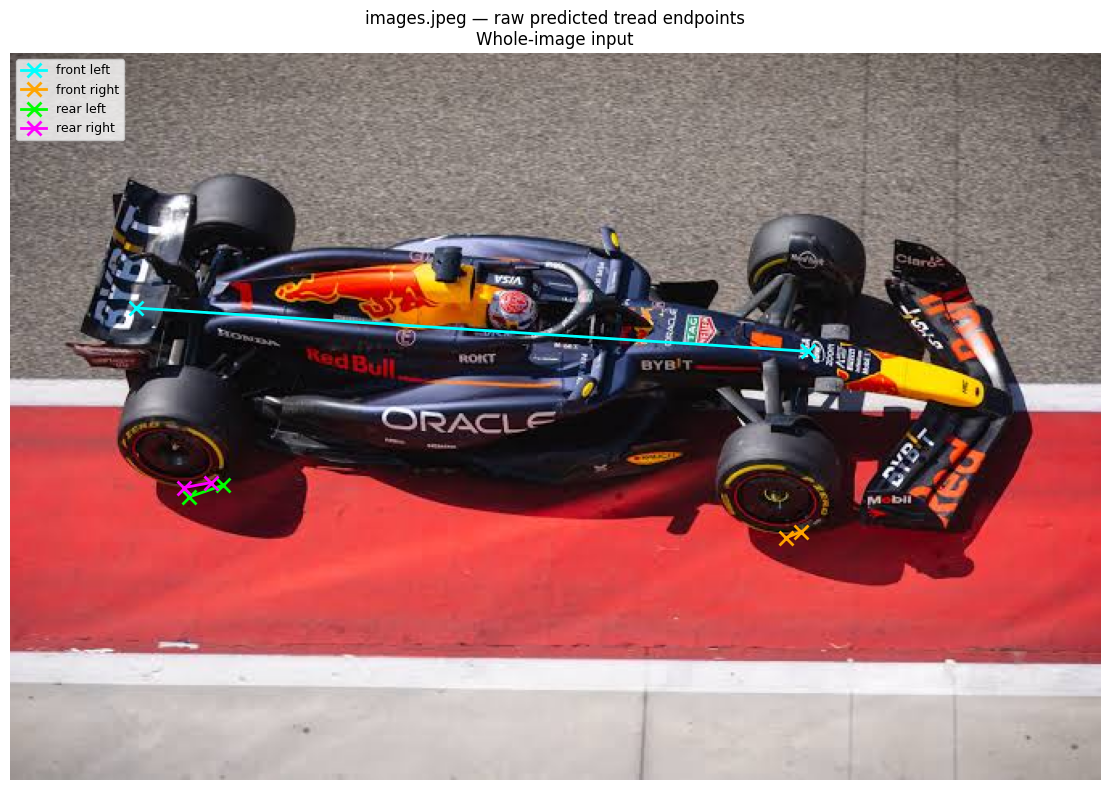

images.jpeg: 0/8 predicted points outside the image. Dashed = diffuse heatmap; solid does not mean correct.


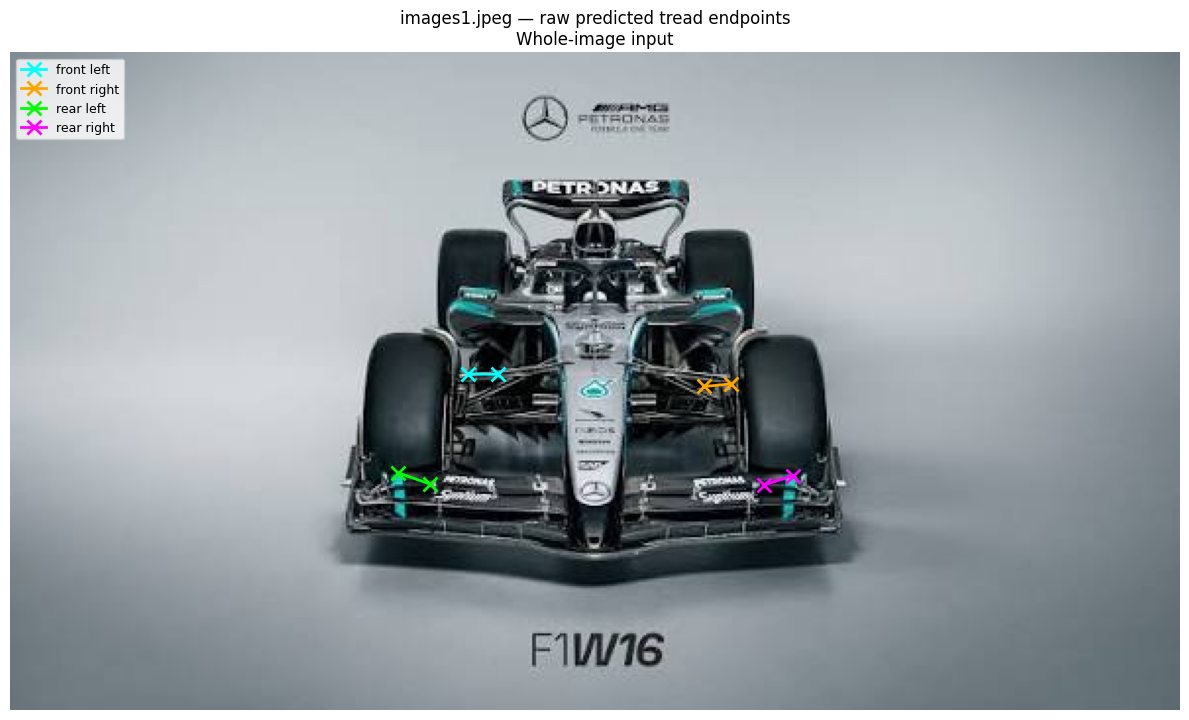

images1.jpeg: 0/8 predicted points outside the image. Dashed = diffuse heatmap; solid does not mean correct.


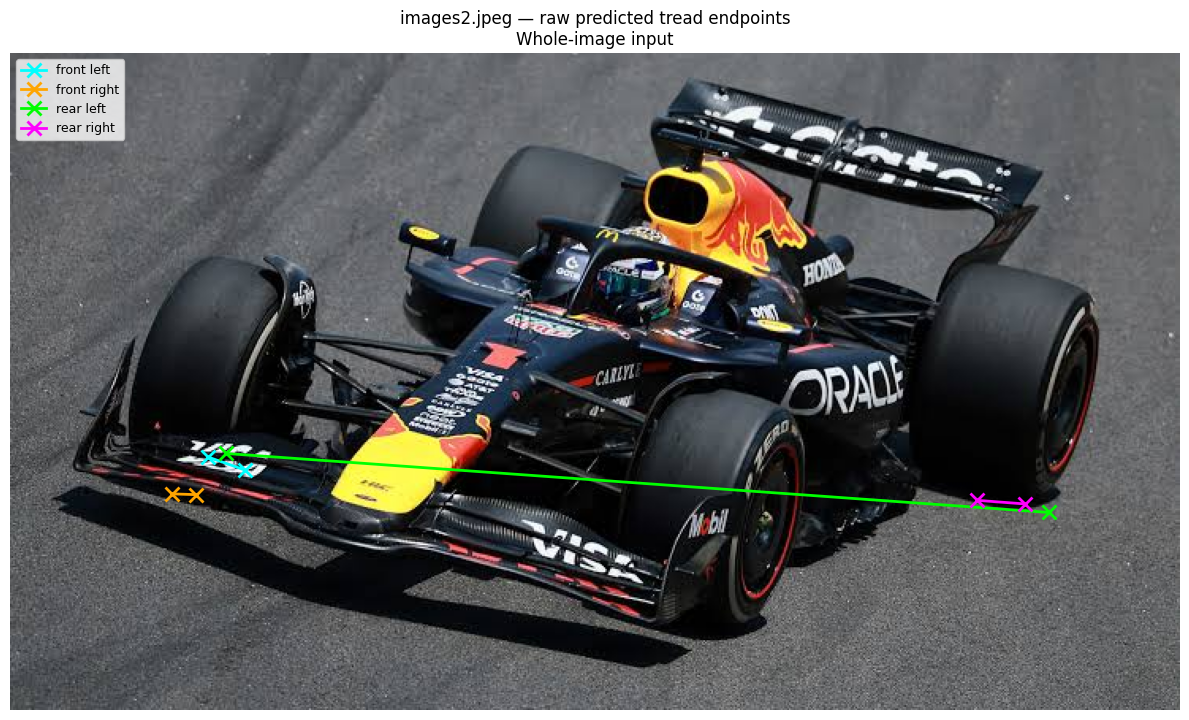

images2.jpeg: 0/8 predicted points outside the image. Dashed = diffuse heatmap; solid does not mean correct.
Saved overlays and raw coordinates to: /home/aditya/work/trackshift/training_runs/real_image_preview_20260912_234150_787556


In [18]:
# Run independently: no training or simulator camera calibration is needed.
from pathlib import Path
from datetime import datetime
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import boundary_training as bt

_REAL_ROOT = next((p for p in [Path.cwd(), Path.cwd().parent] if (p / "data" / "real_imgs").is_dir()), Path.cwd())
REAL_IMAGE_DIR = _REAL_ROOT / "data" / "real_imgs"
# Optional filename -> (x, y, width, height) around ONE car, measured in source pixels.
# Missing entries use the whole image. Set boxes for wider shots or multiple cars.
REAL_CAR_BOXES = {}  # e.g. {"photo.jpg": (100, 80, 500, 250)}
REAL_CHECKPOINT = None  # Optional Path("training_runs/.../best_model"). None = newest saved heatmap checkpoint.
_real_files = sorted(p for p in REAL_IMAGE_DIR.rglob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".webp", ".bmp"})
if not _real_files:
    raise FileNotFoundError(f"No supported images found in {REAL_IMAGE_DIR}")
if REAL_CHECKPOINT is None:
    _real_checkpoints = list((_REAL_ROOT / "training_runs").glob("*/best_model/boundary_heatmaps.pt"))
    if not _real_checkpoints:
        raise FileNotFoundError("No trained heatmap checkpoint found. Set REAL_CHECKPOINT to your best_model folder.")
    REAL_CHECKPOINT = max(_real_checkpoints, key=lambda p: p.stat().st_mtime).parent
_real_device = "cuda" if torch.cuda.is_available() else "cpu"
_real_nvrtc = bt.preload_nvrtc() if _real_device == "cuda" else None
print(f"Loading {REAL_CHECKPOINT} on {_real_device}", flush=True)
_real_model, _real_processor, _real_config, _ = bt.load_checkpoint(REAL_CHECKPOINT, _real_device)
REAL_OUTPUT_DIR = _REAL_ROOT / "training_runs" / datetime.now().strftime("real_image_preview_%Y%m%d_%H%M%S_%f")
REAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
_real_colors = ["cyan", "orange", "lime", "magenta"]
_real_predictions = []
for _real_idx, _real_path in enumerate(_real_files):
    with Image.open(_real_path) as _im:
        _rgb = np.asarray(ImageOps.exif_transpose(_im).convert("RGB"))
    _h, _w = _rgb.shape[:2]
    _key = _real_path.relative_to(REAL_IMAGE_DIR).as_posix()
    _box = REAL_CAR_BOXES.get(_key)
    if _box is None:
        _side = max(_w, _h)
        _crop = (int(round((_w-_side)/2)), int(round((_h-_side)/2)), _side)
    else:
        _x, _y, _bw, _bh = _box
        if not (0 <= _x < _w and 0 <= _y < _h and _bw > 0 and _bh > 0 and _x+_bw <= _w and _y+_bh <= _h):
            raise ValueError(f"Invalid car box for {_key}: {_box}")
        _side = int(np.ceil(max(_bw, _bh) * _real_config.crop_padding + 16))
        _crop = (int(round(_x+_bw/2-_side/2)), int(round(_y+_bh/2-_side/2)), _side)
    _input = bt.crop_image(_rgb, _crop, _real_config.image_size)
    with torch.inference_mode():
        _pixels = _real_processor(images=_input, return_tensors="pt")["pixel_values"].to(_real_device)
        _points, _mass = bt.decode_heatmaps(_real_model(_pixels), _real_config)
    _uv = bt.from_crop(_points[0].cpu().numpy(), _crop, _real_config.image_size)
    _scores = _mass[0].cpu().numpy()
    _fig, _ax = plt.subplots(figsize=(12, 8))
    _ax.imshow(_rgb)
    for _j, (_wheel, _color) in enumerate(zip(bt.WHEELS, _real_colors)):
        _pair = _uv[2*_j:2*_j+2]
        _diffuse = bool(np.any(_scores[2*_j:2*_j+2] < _real_config.min_peak_mass))
        _ax.plot(_pair[:, 0], _pair[:, 1], "x--" if _diffuse else "x-", color=_color,
                 markersize=10, markeredgewidth=2, linewidth=2,
                 label=_wheel.replace("_", " ") + (" (diffuse)" if _diffuse else ""))
    _outside = int(np.sum(np.any((_uv < 0) | (_uv >= [_w, _h]), axis=1)))
    _ax.set_xlim(-.5, _w-.5); _ax.set_ylim(_h-.5, -.5); _ax.axis("off")
    _ax.set_title(f"{_key} — raw predicted tread endpoints\nWhole-image input" if _box is None else f"{_key} — raw predicted tread endpoints\nManual car crop")
    _ax.legend(loc="upper left", fontsize=9)
    _fig.tight_layout()
    _fig.savefig(REAL_OUTPUT_DIR / f"{_real_idx:03d}_{_real_path.stem}_tyres.png", dpi=150)
    plt.show(); plt.close(_fig)
    print(f"{_key}: {_outside}/8 predicted points outside the image. Dashed = diffuse heatmap; solid does not mean correct.", flush=True)
    _real_predictions.append(dict(image=str(_real_path.resolve()), crop=list(_crop),
        points_original_px=_uv.tolist(), endpoint_names=bt.ENDPOINTS, peak_mass_uncalibrated=_scores.tolist()))
bt.save_json(REAL_OUTPUT_DIR / "predictions.json", dict(checkpoint=str(Path(REAL_CHECKPOINT).resolve()),
    note="Unvalidated real-image predictions; no truth labels, calibrated confidence, metric distances or violation verdicts.", images=_real_predictions))
print("Saved overlays and raw coordinates to:", REAL_OUTPUT_DIR)
# Release this cell's separate model; the notebook's training model is untouched.
del _real_model, _pixels
if _real_device == "cuda": torch.cuda.empty_cache()
